# Entrega #1 Proyecto redes Neuronales
## *Clasificación de Texto con Redes Neuronales*
### **Dataset**: Twitter US Airline Sentiment Dataset
Mensajes de Twitter en inglés sobre las principales aerolíneas estadounidenses clasificados por sentimientos como: positive, negative, neutral. Se recopilaron datos de Twitter en febrero de 2015

**Fuente:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

Oscar David Cuaical Lopez

202270657

cuaical.oscar@correounivalle.edu.co

## **1. Importaciones**

Se importan las librerías necesarias para:
- Manipulación de datos (pandas, numpy)
- Preprocesamiento de texto (TF-IDF, SVD, escalado)
- División de dataset y métricas (train_test_split, confusion_matrix)
- Creación y entrenamiento del modelo MLP (Keras)
- Visualización de resultados (matplotlib, seaborn)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Carga del dataset**

El dataset se carga directamente desde un repositorio de GitHub.

Esto permite que cualquier persona pueda
ejecutar el código sin necesidad de subir manualmente el archivo.

Dataset: Twitter US Airline Sentiment (Kaggle)

In [ ]:
url = "https://raw.githubusercontent.com/oscar-230/Dataset-Twitter/main/Tweets.csv"
df = pd.read_csv(url)

print("Columnas disponibles:", df.columns.tolist())
print("\nPrimeras filas:")
df.head()

Columnas disponibles: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Primeras filas:


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## **3. Preprocesamiento del dataset**

- Se selecciona solo el texto y la etiqueta de sentimiento
- Se convierten las etiquetas (negative, neutral, positive) a valores numéricos
- Se vectoriza el texto con TF-IDF (1 y 2-gramas, 2000 features)
- Se aplica reducción de dimensionalidad con SVD (300 componentes)
- Se escalan los datos para mejorar el entrenamiento del modelo
- Se dividen los datos en train (70%), validation (10%), test (20%)

In [ ]:
# Selección de columnas
df = df[['text','airline_sentiment']]

# Mapear etiquetas a números
label_map = {'negative':0, 'neutral':1, 'positive':2}
df = df[df['airline_sentiment'].isin(label_map.keys())]
df['label'] = df['airline_sentiment'].map(label_map)

print("Distribución de clases:")
print(df['airline_sentiment'].value_counts())

# Vectorización TF-IDF
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,2), stop_words='english')
X_tfidf = vectorizer.fit_transform(df['text'])

# Reducción de dimensionalidad
svd = TruncatedSVD(n_components=300, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

# Escalado
scaler = StandardScaler()
X_reduced = scaler.fit_transform(X_reduced)

# División en train/val/test
X_train, X_test, y_train, y_test, txt_train, txt_test = train_test_split(
    X_reduced, df['label'].values, df['text'].values,
    test_size=0.20, stratify=df['label'].values, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1111, stratify=y_train, random_state=42
)

print("Shapes -> train:", X_train.shape, " val:", X_val.shape, " test:", X_test.shape)

Distribución de clases:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
Shapes -> train: (10410, 300)  val: (1302, 300)  test: (2928, 300)


## **4. Cálculo de pesos de clase**

Debido al desbalance en las clases (más negativos que positivos),
se calculan los pesos de clase.

Esto permite al modelo no "ignorar"
las clases minoritarias y entrenar de manera más justa.

In [ ]:
classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
print("Pesos de clase:", class_weight)

Pesos de clase: {0: 0.5316378121648537, 1: 1.575124829777576, 2: 2.0654761904761907}


## **5. Modelo Perceptrón Multicapa (MLP)**

### Arquitectura:
- Capa de entrada: 300 neuronas (tras SVD)
- 1ra capa oculta: 32 neuronas, ReLU, regularización L2
- Dropout 50% para evitar sobreajuste
- 2da capa oculta: 16 neuronas, ReLU, regularización L2
- Dropout 50%
- Capa de salida: 3 neuronas (softmax) para clasificación multiclase

### Hiperparámetros:
- Optimizador: Adam (lr=1e-4)
- Función de pérdida: SparseCategoricalCrossentropy
- Métrica: Accuracy

In [ ]:
NEURONAS_1 = 32
NEURONAS_2 = 16
DROPOUT_RATE = 0.5
L2 = 1e-4
LR = 1e-4
EPOCHS = 100
BATCH = 32

model = models.Sequential([
    layers.Dense(NEURONAS_1, activation='relu', input_shape=(X_train.shape[1],),
                 kernel_regularizer=regularizers.l2(L2)),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(NEURONAS_2, activation='relu', kernel_regularizer=regularizers.l2(L2)),
    layers.Dropout(DROPOUT_RATE),
    layers.Dense(3, activation='softmax')
])

opt = tf.keras.optimizers.Adam(learning_rate=LR)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_45 (Dense)                │ (None, 32)             │         9,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,211 (39.89 KB)

 Trainable params: 10,211 (39.89 KB)

 Non-trainable params: 0 (0.00 B)

## **6. Entrenamiento**

Se entrena el modelo con Early Stopping para evitar sobreajuste.

Se usa validación en cada época y los mejores pesos se restauran automáticamente.

In [ ]:
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[es],
    verbose=1
)

Epoch 1/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3566 - loss: 1.7914 - val_accuracy: 0.3402 - val_loss: 1.1888
Epoch 2/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3657 - loss: 1.5808 - val_accuracy: 0.3679 - val_loss: 1.1408
Epoch 3/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3719 - loss: 1.4433 - val_accuracy: 0.3710 - val_loss: 1.1179
Epoch 4/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3698 - loss: 1.3475 - val_accuracy: 0.3802 - val_loss: 1.1053
Epoch 5/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3718 - loss: 1.2851 - val_accuracy: 0.3879 - val_loss: 1.0933
Epoch 6/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3700 - loss: 1.2119 - val_accuracy: 0.3879 - val_loss: 1.0858
Epoch 7/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3844 - loss: 1.1963 - val_accuracy: 0.3940 - val_loss: 1.0799
Epoch 8/100
326/326 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3770 - loss: 1.1419 - val_accu

## **7. Curvas de entrenamiento**

Se grafican las curvas de pérdida y accuracy para observar:
- La evolución durante el entrenamiento
- Si hubo sobreajuste
- Cuándo se activó el EarlyStopping

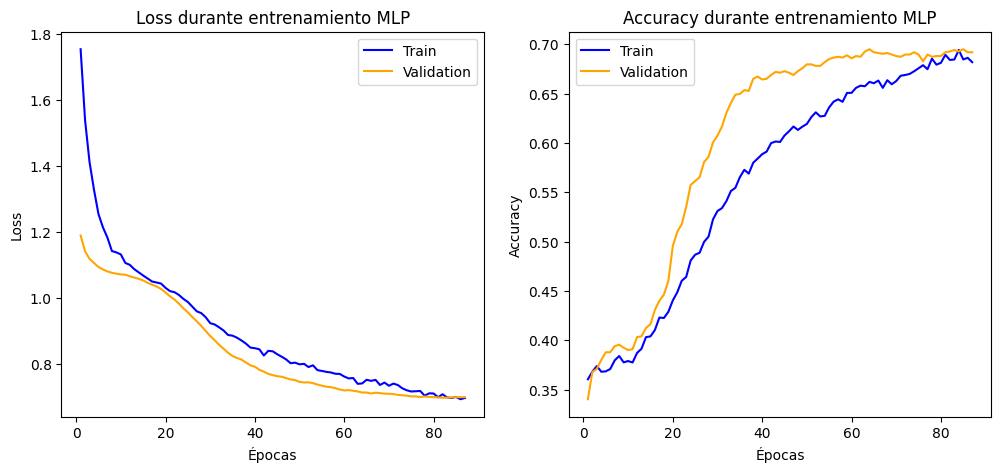

In [ ]:
def plot_training_curves(history, title_suffix="A"):
    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(epochs_range, loss, 'b-', label='Train')
    plt.plot(epochs_range, val_loss, 'orange', label='Validation')
    plt.title(f"Loss durante entrenamiento {title_suffix}")
    plt.xlabel("Épocas")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(epochs_range, acc, 'b-', label='Train')
    plt.plot(epochs_range, val_acc, 'orange', label='Validation')
    plt.title(f"Accuracy durante entrenamiento {title_suffix}")
    plt.xlabel("Épocas")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.show()

plot_training_curves(history, title_suffix="MLP")

## **8. Evaluación final**

Se evalúa el modelo en el conjunto de test:
- Accuracy final
- Reporte de clasificación (precision, recall, f1)
- Matriz de confusión normalizada

Test acc: 0.6994535326957703
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

    negative       0.89      0.70      0.78      1835
     neutral       0.48      0.69      0.57       620
    positive       0.56      0.71      0.63       473

    accuracy                           0.70      2928
   macro avg       0.65      0.70      0.66      2928
weighted avg       0.75      0.70      0.71      2928



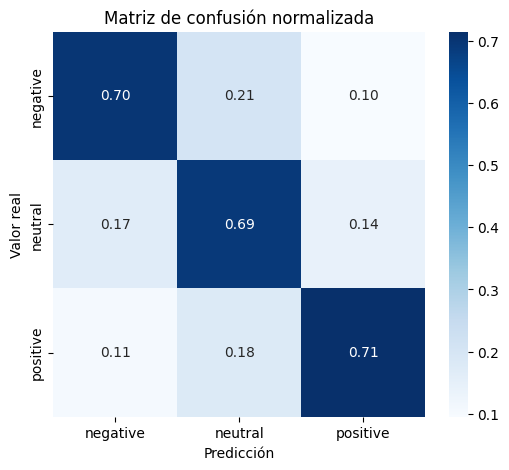

In [ ]:
# Accuracy en test
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test acc:", test_acc)

# Reporte de clasificación
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred, target_names=['negative','neutral','positive']))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión normalizada')
plt.show()